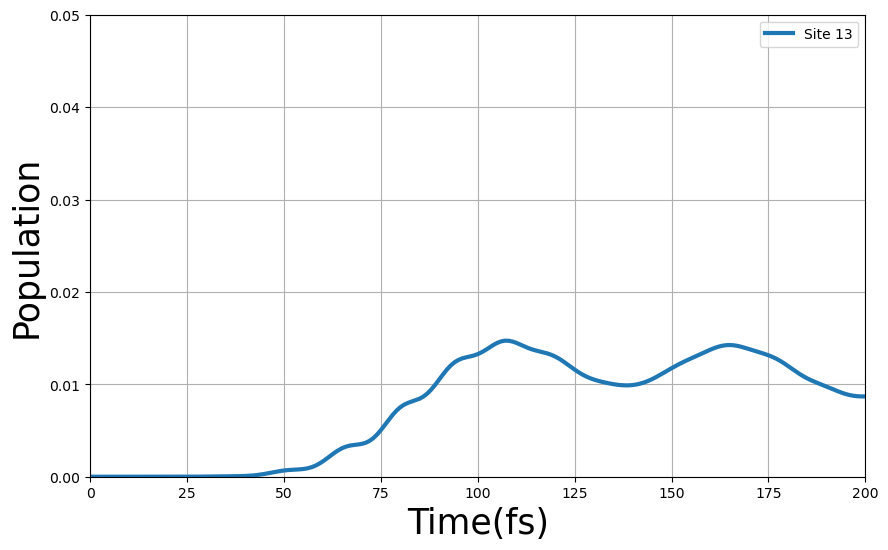

In [6]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
# multiset_ttn/P3HT:PCBM/singleset_tree/p3ht_ttns_tree_bond_entropy_32.npz
npz_path = Path("../multiset_treeX_bond_entropy/p3ht_ms_ttn_treeX_bond_entropy_32.npz")
site_columns = [12]
dt_fs = 1.0

data = np.load(npz_path, allow_pickle=True)
population = data["e_occupations"]
x = np.arange(population.shape[0]) * dt_fs

plt.figure(figsize=(10, 6))
for site in site_columns:
    plt.plot(x, population[:, site], label=f"Site {site + 1}", linewidth=3)

plt.xlabel("Time(fs)", size=25)
plt.ylabel("Population", size=25)
plt.xlim(0, 200)
plt.ylim(0, 0.05)
plt.legend()
plt.grid(True)
plt.show()


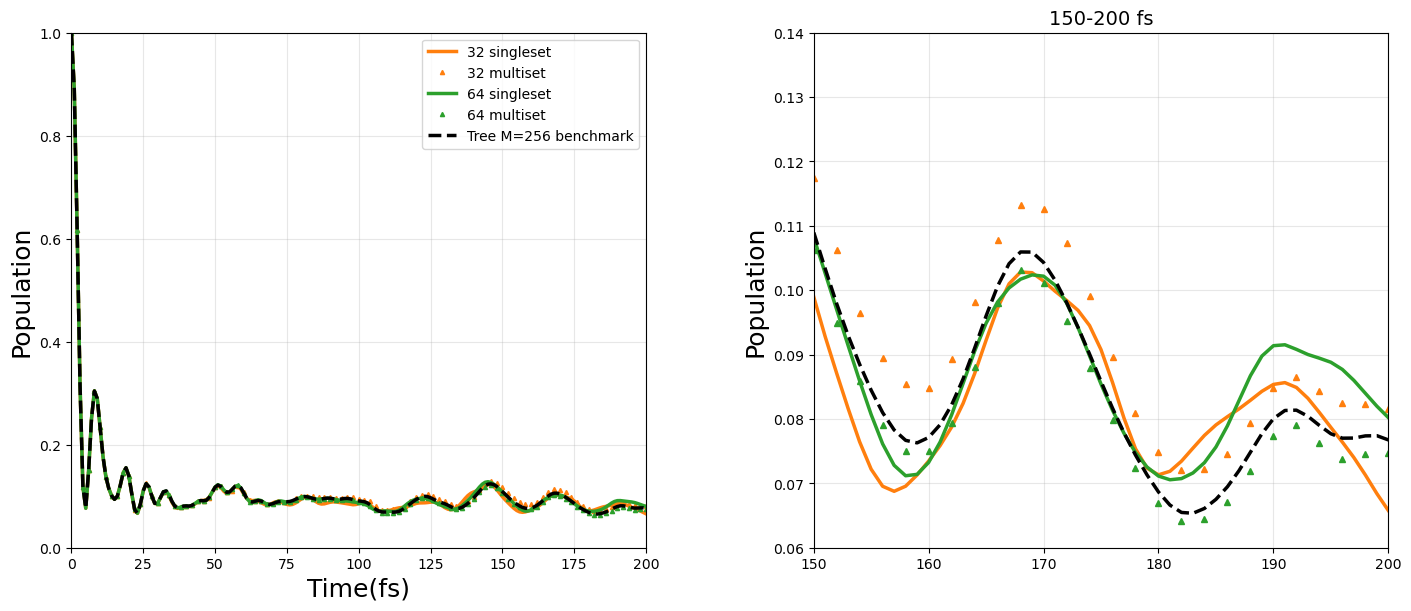

In [5]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

datasets = [
    # ('16', 'p3ht_16_multiset.xlsx', 'p3ht_16_singleset.xlsx'),
    ('32', 'p3ht_32_multiset.xlsx', 'p3ht_32_singleset.xlsx'),
    ('64', 'p3ht_64_multiset.xlsx', 'p3ht_64_singleset.xlsx'),
    # ('128', 'p3ht_128_multiset.xlsx', 'p3ht_128_singleset.xlsx'),
]

colors = {'16': 'tab:blue', '32': 'tab:orange', '64': 'tab:green', '128': 'tab:red'}
zoom_start, zoom_end = 150, 200
zoom_values = []
plotted = False

fig, (ax, ax_zoom) = plt.subplots(
    1,
    2,
    figsize=(14, 6),
    constrained_layout=True,
    gridspec_kw={'width_ratios': [1, 1], 'wspace': 0.12},
)

for size, multiset_file, singleset_file in datasets:
    multiset_path = Path(multiset_file)
    singleset_path = Path(singleset_file)
    color = colors[size]

    if singleset_path.exists():
        df_single = pd.read_excel(singleset_path)
        x_single = np.arange(df_single.shape[0])
        y_single = df_single.iloc[:, 0:1].iloc[:, 0]
        zoom_values.extend(y_single[(x_single >= zoom_start) & (x_single <= zoom_end)].tolist())

        ax.plot(x_single, y_single, color=color, linewidth=2.5, label=f'{size} singleset')
        ax_zoom.plot(x_single, y_single, color=color, linewidth=2.5)
        plotted = True
    else:
        print(f'Skip {size} singleset: missing {singleset_path}')

    if multiset_path.exists():
        df_multi = pd.read_excel(multiset_path)
        x_multi = np.arange(df_multi.shape[0])
        y_multi = df_multi.iloc[:, 0:1].iloc[:, 0]
        zoom_values.extend(y_multi[(x_multi >= zoom_start) & (x_multi <= zoom_end)].tolist())

        ax.plot(
            x_multi,
            y_multi,
            color=color,
            linestyle='None',
            marker='^',
            markersize=3,
            markevery=2,
            label=f'{size} multiset',
        )
        ax_zoom.plot(
            x_multi,
            y_multi,
            color=color,
            linestyle='None',
            marker='^',
            markersize=5,
            markevery=2,
        )
        plotted = True
    else:
        print(f'Skip {size} multiset: missing {multiset_path}')


benchmark_path = Path("../2026Further_plot/figures/Tree4.npz")
if not benchmark_path.exists():
    benchmark_path = Path("multiset_ttn/P3HT:PCBM/2026Further_plot/figures/Tree4.npz")

if benchmark_path.exists():
    try:
        benchmark_npz = np.load(benchmark_path)
        benchmark_idx = benchmark_npz["M"].astype(str).tolist().index("256")
        y_benchmark = benchmark_npz["n"][benchmark_idx, 0]
        x_benchmark = np.arange(len(y_benchmark))
        zoom_values.extend(y_benchmark[(x_benchmark >= zoom_start) & (x_benchmark <= zoom_end)].tolist())

        ax.plot(
            x_benchmark,
            y_benchmark,
            color="black",
            linestyle="--",
            linewidth=2.5,
            label="Tree M=256 benchmark",
        )
        ax_zoom.plot(
            x_benchmark,
            y_benchmark,
            color="black",
            linestyle="--",
            linewidth=2.5,
        )
        plotted = True
    except (KeyError, ValueError, IndexError) as exc:
        print(f"Skip Tree M=256 benchmark: invalid {benchmark_path}: {exc}")
else:
    print(f"Skip Tree M=256 benchmark: missing {benchmark_path}")

if not plotted:
    plt.close(fig)
    print('Skip plot: no dataset files found')
else:
    ax.set_xlabel('Time(fs)', size=18)
    ax.set_ylabel('Population', size=18)
    ax.set_xlim(0, 200)
    ax.set_ylim(0, 1)
    ax.grid(True, alpha=0.3)
    ax.legend()

    ax_zoom.set_xlim(zoom_start, zoom_end)
    if zoom_values:
        zoom_min = min(zoom_values)
        zoom_max = max(zoom_values)
        zoom_margin = max((zoom_max - zoom_min) * 0.1, 1e-4)
        ax_zoom.set_ylim(zoom_min - zoom_margin, zoom_max + zoom_margin)
    ax_zoom.set_ylim(0.06, 0.14)
    ax_zoom.set_ylabel('Population', size=18)
    ax_zoom.set_title('150-200 fs', size=14)
    ax_zoom.grid(True, alpha=0.3)

    plt.show()


16 multiset treeX: max ACE=6.1360e-03, mean ACE=2.8856e-03
32 multiset treeX: max ACE=2.4053e-03, mean ACE=9.2981e-04
32 singleset: max ACE=3.9130e-03, mean ACE=1.9325e-03
32 multiset: max ACE=3.5094e-03, mean ACE=1.3895e-03
64 multiset treeX: max ACE=1.4100e-03, mean ACE=4.9513e-04
64 singleset: max ACE=2.3384e-03, mean ACE=7.8223e-04
64 multiset: max ACE=1.1973e-03, mean ACE=4.2106e-04


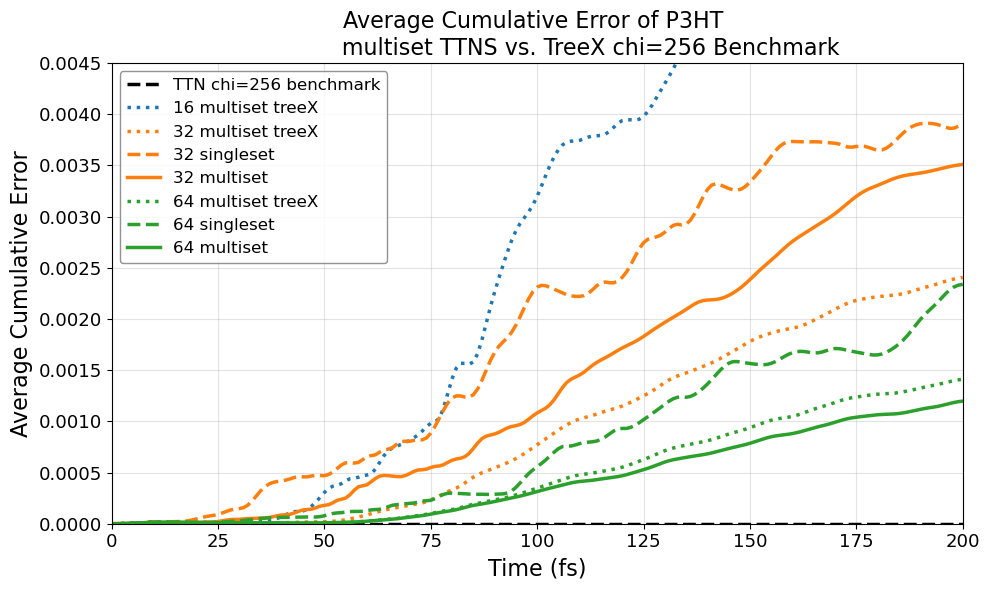

In [13]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

benchmark_path = Path("../../../multiset_ttn/P3HT:PCBM/2026Further_plot/figures/Tree4.npz")
if not benchmark_path.exists():
    benchmark_path = Path("multiset_ttn/P3HT:PCBM/2026Further_plot/figures/Tree4.npz")

data_files = [
    ("16 multiset treeX", Path("p3ht_16_multiset_treeX.xlsx"), "tab:blue", ":"),
    ("32 multiset treeX", Path("p3ht_32_multiset_treeX.xlsx"), "tab:orange", ":"),
    ("32 singleset", Path("p3ht_32_singleset.xlsx"), "tab:orange", "--"),
    ("32 multiset", Path("p3ht_32_multiset.xlsx"), "tab:orange", "-"),
    ("64 multiset treeX", Path("p3ht_64_multiset_treeX.xlsx"), "tab:green", ":"),
    ("64 singleset", Path("p3ht_64_singleset.xlsx"), "tab:green", "--"),
    ("64 multiset", Path("p3ht_64_multiset.xlsx"), "tab:green", "-"),
    # ("128 singleset", Path("p3ht_128_singleset.xlsx"), "tab:red", "--"),
    # ("128 multiset", Path("p3ht_128_multiset.xlsx"), "tab:red", "-"),
]

dt_fs = 1.0


def cumulative_error(y, y_ref, x, x_ref):
    y_ref_interp = np.interp(x, x_ref, y_ref)
    abs_err = np.abs(y - y_ref_interp)
    err = np.zeros(len(x), dtype=float)
    if len(x) > 1:
        seg_integral = 0.5 * (abs_err[1:] + abs_err[:-1]) * np.diff(x)
        err[1:] = np.cumsum(seg_integral) / x[1:]
    return err


if not benchmark_path.exists():
    print(f"Skip cumulative error plot: missing {benchmark_path}")
else:
    benchmark_npz = np.load(benchmark_path)
    benchmark_idx = benchmark_npz["M"].astype(str).tolist().index("256")
    y_ref = benchmark_npz["n"][benchmark_idx, 0].astype(float)
    x_ref = np.arange(len(y_ref)) * dt_fs

    fig, ax = plt.subplots(figsize=(10, 6))
    plotted = False
    ax.plot(x_ref, np.zeros_like(x_ref), color="black", linestyle="--", linewidth=2.5, label="TTN chi=256 benchmark")

    for label, path, color, linestyle in data_files:
        if not path.exists():
            print(f"Skip {label}: missing {path}")
            continue

        y = pd.read_excel(path).iloc[:, 0].to_numpy(dtype=float)
        x = np.arange(len(y)) * dt_fs
        err = cumulative_error(y, y_ref, x, x_ref)
        ax.plot(x, err, label=label, color=color, linestyle=linestyle, linewidth=2.5)
        plotted = True
        print(f"{label}: max ACE={err.max():.4e}, mean ACE={err.mean():.4e}")

    if not plotted:
        plt.close(fig)
        print("Skip cumulative error plot: no data files found")
    else:
        ax.set_xlabel("Time (fs)", fontsize=16)
        ax.set_ylabel("Average Cumulative Error", fontsize=16)
        ax.set_title("Average Cumulative Error of P3HT \n" \
        "               multiset TTNS vs. TreeX chi=256 Benchmark", fontsize=16)
        ax.set_xlim(0, 200)
        ax.set_ylim(bottom=0,top=0.0045)
        ax.tick_params(labelsize=13)
        ax.legend(fontsize=12, framealpha=0.85, edgecolor="gray")
        ax.grid(True, alpha=0.35)
        plt.tight_layout()
        plt.savefig("P3HT_avg_cumulative_error_vs_ttn_chi256.png", dpi=150)
        plt.show()


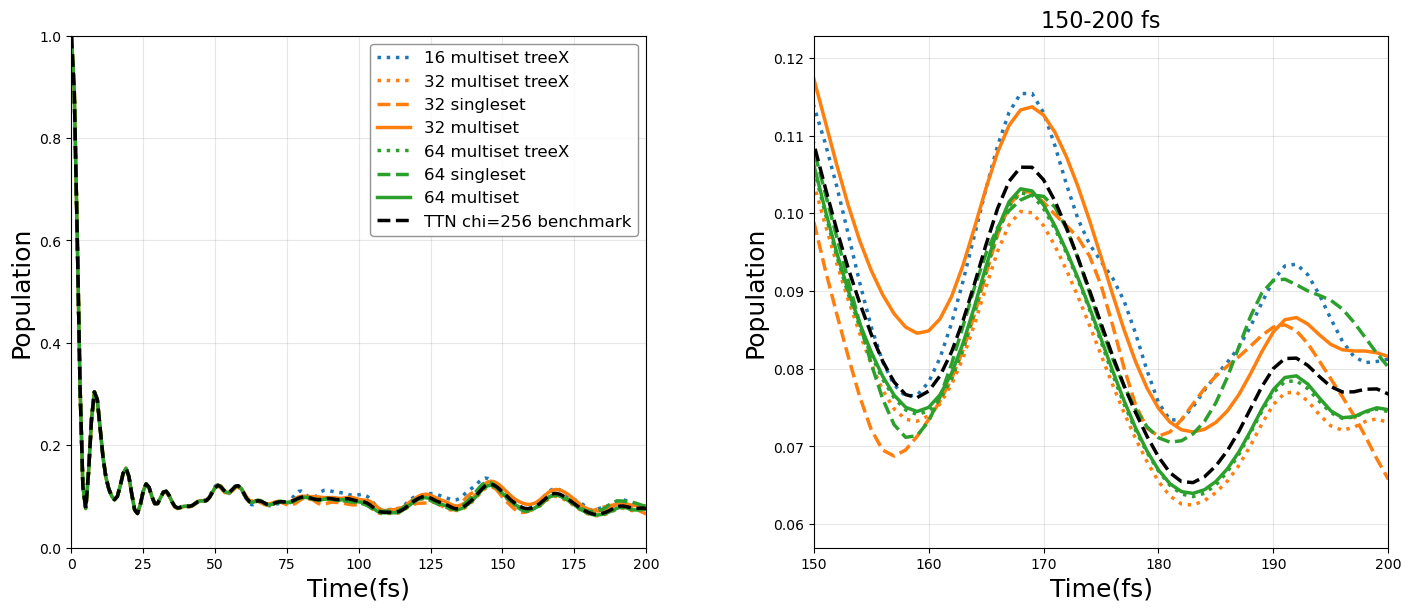

In [14]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Normal Excel inputs. Comment/uncomment rows here to choose what to plot.
data_files = [
    ("16 multiset treeX", Path("p3ht_16_multiset_treeX.xlsx"), "tab:blue", ":"),
    ("32 multiset treeX", Path("p3ht_32_multiset_treeX.xlsx"), "tab:orange", ":"),
    ("32 singleset", Path("p3ht_32_singleset.xlsx"), "tab:orange", "--"),
    ("32 multiset", Path("p3ht_32_multiset.xlsx"), "tab:orange", "-"),
    ("64 multiset treeX", Path("p3ht_64_multiset_treeX.xlsx"), "tab:green", ":"),
    ("64 singleset", Path("p3ht_64_singleset.xlsx"), "tab:green", "--"),
    ("64 multiset", Path("p3ht_64_multiset.xlsx"), "tab:green", "-"),
    # ("128 singleset", Path("p3ht_128_singleset.xlsx"), "tab:red", "--"),
    # ("128 multiset", Path("p3ht_128_multiset.xlsx"), "tab:red", "-"),
]

# Benchmark npz inputs. Tuple fields are: label, path, color, linestyle, M value, site index.
benchmark_files = [
    ("TTN chi=256 benchmark", Path("../2026Further_plot/figures/Tree4.npz"), "black", "--", "256", 0),
]

dt_fs = 1.0
zoom_start, zoom_end = 150, 200


def resolve_input_path(path):
    path = Path(path)
    candidates = [path]
    if not path.is_absolute():
        candidates.append(Path("multiset_ttn/P3HT:PCBM/plot") / path)
    for candidate in candidates:
        if candidate.exists():
            return candidate
    return path


def plot_series(ax, ax_zoom, x, y, label, color, linestyle):
    ax.plot(x, y, label=label, color=color, linestyle=linestyle, linewidth=2.5)
    ax_zoom.plot(x, y, color=color, linestyle=linestyle, linewidth=2.5)


zoom_values = []
plotted = False
fig, (ax, ax_zoom) = plt.subplots(
    1,
    2,
    figsize=(14, 6),
    constrained_layout=True,
    gridspec_kw={"width_ratios": [1, 1], "wspace": 0.12},
)

for label, path, color, linestyle in data_files:
    path = resolve_input_path(path)
    if not path.exists():
        print(f"Skip {label}: missing {path}")
        continue

    try:
        y = pd.read_excel(path).iloc[:, 0].to_numpy(dtype=float)
    except Exception as exc:
        print(f"Skip {label}: failed to read {path}: {exc}")
        continue

    x = np.arange(len(y)) * dt_fs
    zoom_values.extend(y[(x >= zoom_start) & (x <= zoom_end)].tolist())
    plot_series(ax, ax_zoom, x, y, label, color, linestyle)
    plotted = True

for label, path, color, linestyle, m_value, site_index in benchmark_files:
    path = resolve_input_path(path)
    if not path.exists():
        print(f"Skip {label}: missing {path}")
        continue

    try:
        benchmark_npz = np.load(path)
        benchmark_idx = benchmark_npz["M"].astype(str).tolist().index(str(m_value))
        y = benchmark_npz["n"][benchmark_idx, site_index].astype(float)
    except Exception as exc:
        print(f"Skip {label}: failed to read {path}: {exc}")
        continue

    x = np.arange(len(y)) * dt_fs
    zoom_values.extend(y[(x >= zoom_start) & (x <= zoom_end)].tolist())
    plot_series(ax, ax_zoom, x, y, label, color, linestyle)
    plotted = True

if not plotted:
    plt.close(fig)
    print("Skip plot: no data files found")
else:
    ax.set_xlabel("Time(fs)", size=18)
    ax.set_ylabel("Population", size=18)
    ax.set_xlim(0, 200)
    ax.set_ylim(0, 1)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=12, framealpha=0.85, edgecolor="gray")

    ax_zoom.set_xlabel("Time(fs)", size=18)
    ax_zoom.set_ylabel("Population", size=18)
    ax_zoom.set_xlim(zoom_start, zoom_end)
    if zoom_values:
        zoom_min = min(zoom_values)
        zoom_max = max(zoom_values)
        zoom_margin = max((zoom_max - zoom_min) * 0.1, 1e-4)
        ax_zoom.set_ylim(zoom_min - zoom_margin, zoom_max + zoom_margin)
    ax_zoom.set_title(f"{zoom_start}-{zoom_end} fs", size=16)
    ax_zoom.grid(True, alpha=0.3)

    plt.show()
